--------------------------------------
DATA LENGTH: 613
DATA SHAPE: (613, 8)
DATA HEAD:    coApplicantIncomeZ  loanAmountZ  loanAmountTermZ  gender  isMarried  \
0           -0.554036    -0.210713         0.273009       1          0   
1           -0.038700    -0.210713         0.273009       1          1   
2           -0.554036    -0.947840         0.273009       1          1   
3            0.251774    -0.305826         0.273009       1          1   
4           -0.554036    -0.056154         0.273009       1          0   

   isEducated  isSelfEmployed  targetLoanStatus  
0           1               0                 1  
1           1               0                 0  
2           1               1                 1  
3           0               0                 1  
4           1               0                 1  
--------------------------------------
# RANDOM FOREST TRAINING
Accuracy: 58.44%
Precision: 62.99%
Recall: 82.47%
F1-Score: 71.43%
Confusion Matrix:
 [[10 47]
 [17 80]

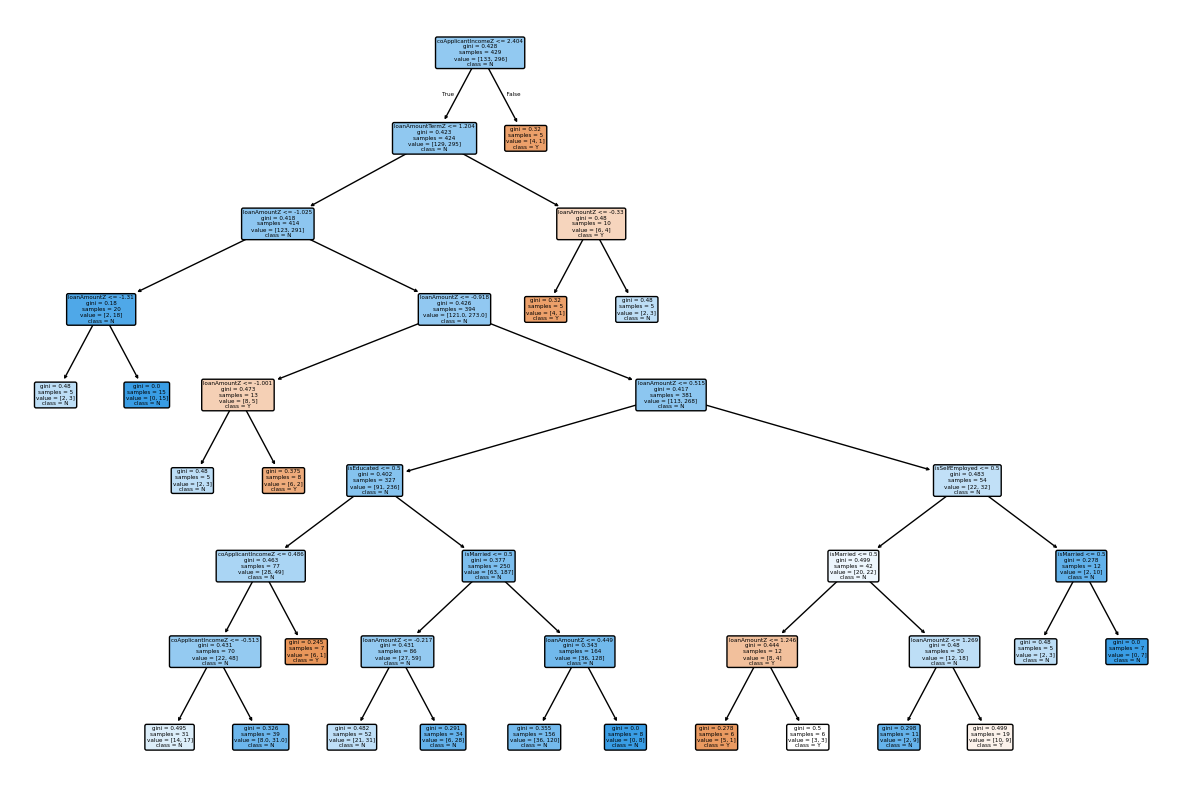

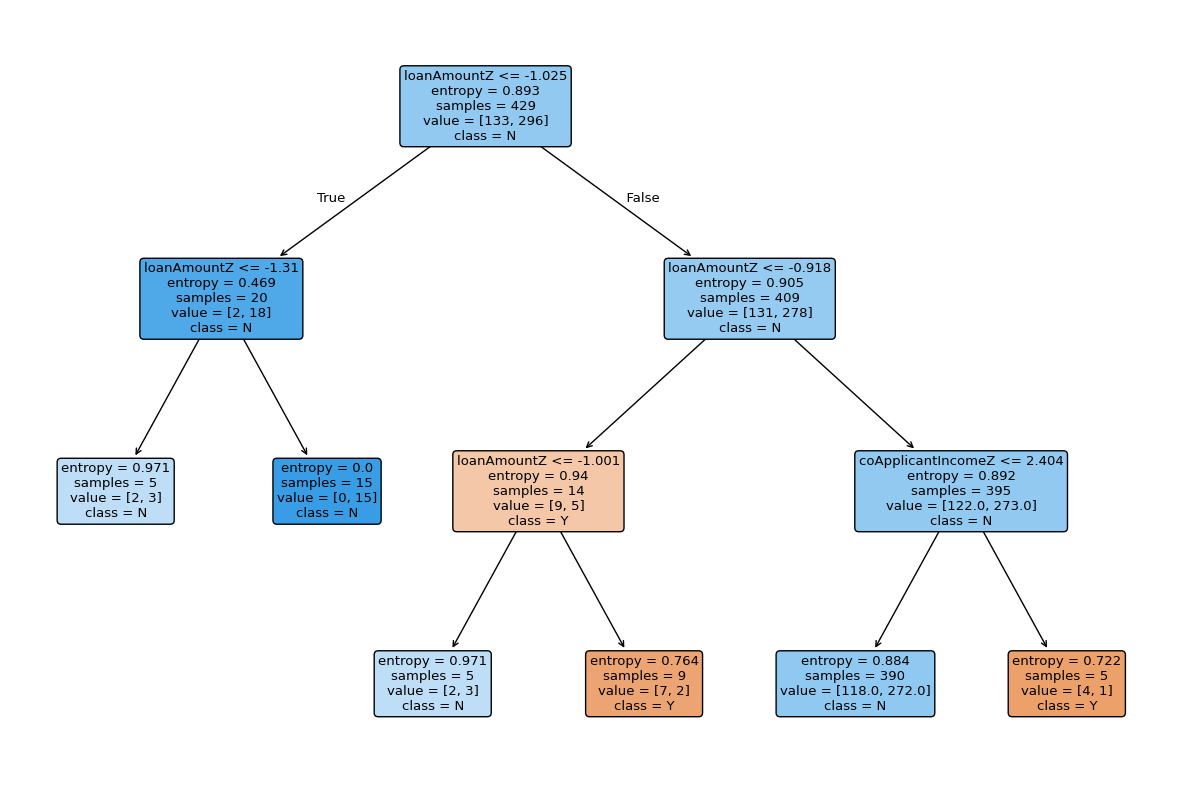

Best DT Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2}
Best CV F1-Score:    0.8234
Best RF Parameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 50}
Best CV F1-Score:    0.8177
                Model  Accuracy  Precision  Recall  F1-Score
Baseline DT (Entropy)    0.6793     0.6851  0.9841    0.8078
  Tuned Decision Tree    0.6848     0.6889  0.9841    0.8105
  Tuned Random Forest    0.6848     0.6848  1.0000    0.8129
=== 5-FOLD STRATIFIED CROSS-VALIDATION (Tuned Decision Tree) ===
Accuracy    : [0.6748 0.6829 0.6829 0.6967 0.6885]  |  Mean: 0.6852  Std: 0.0072
F1          : [0.8039 0.8079 0.8098 0.8177 0.8155]  |  Mean: 0.8110  Std: 0.0050
Precision   : [0.6891 0.6949 0.686  0.6975 0.6885]  |  Mean: 0.6912  Std: 0.0043
Recall      : [0.9647 0.9647 0.9881 0.9881 1.    ]  |  Mean: 0.9811  Std: 0.0141
Saved: 413DM-P3-hyperparam-results.csv
Saved: 413DM-P3-cv-results.csv


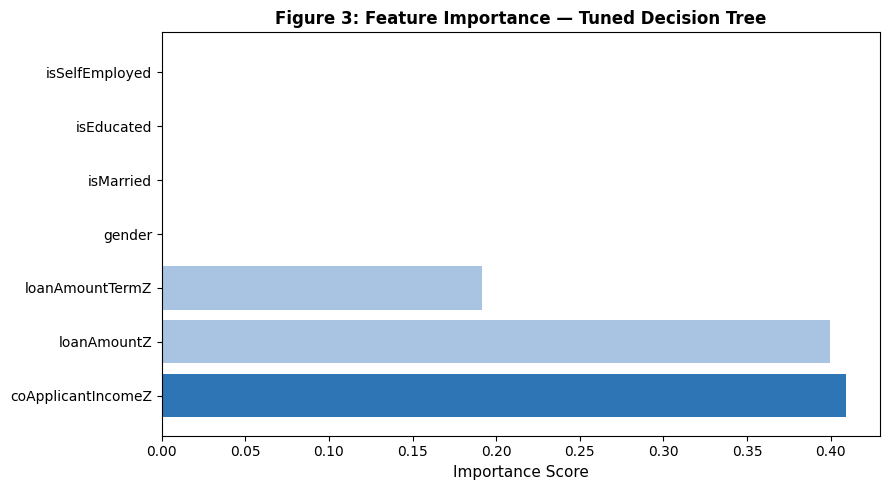

           Feature  Importance
coApplicantIncomeZ    0.409031
       loanAmountZ    0.399428
   loanAmountTermZ    0.191541
            gender    0.000000
         isMarried    0.000000
        isEducated    0.000000
    isSelfEmployed    0.000000


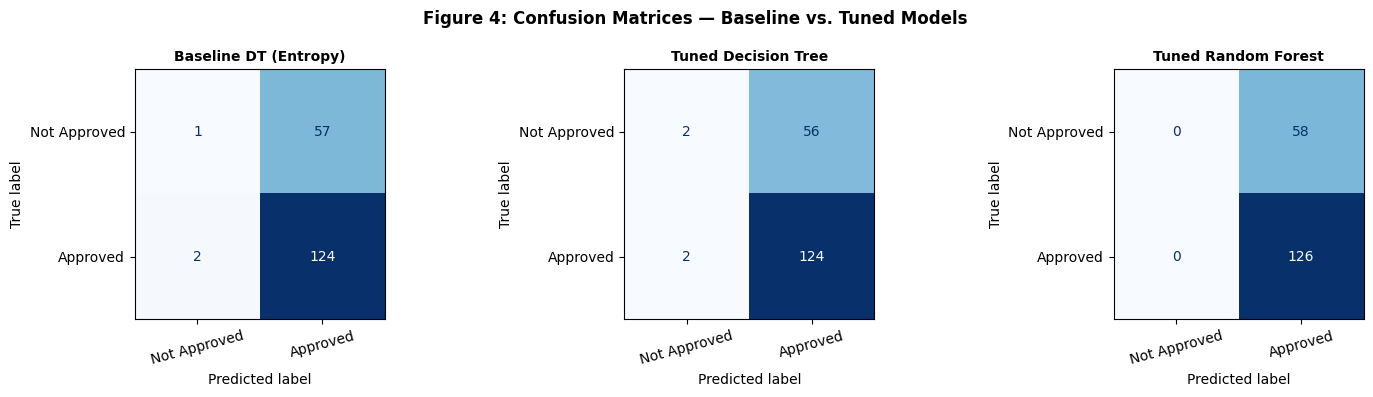

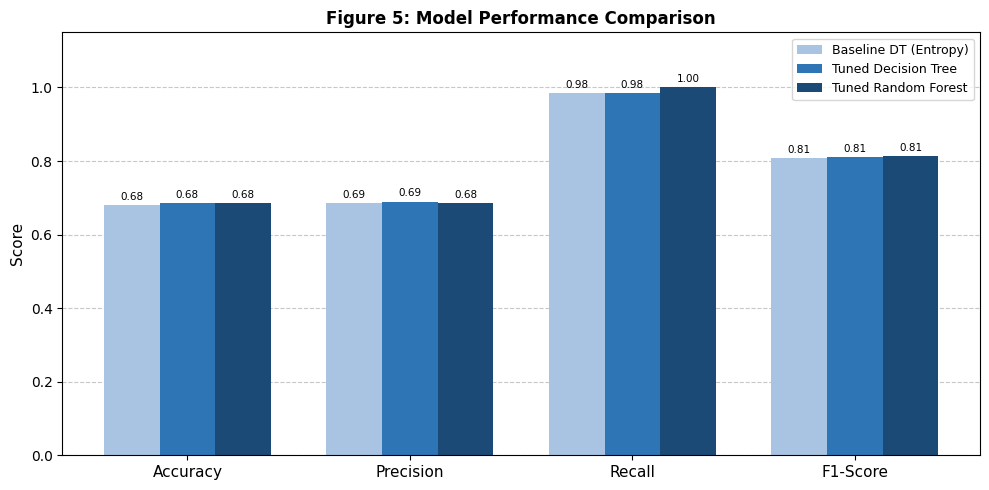

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


df = pd.read_csv("https://raw.githubusercontent.com/carocledc3/snippets/refs/heads/main/T41/413DM-P3-DS.csv")

X = df[['coApplicantIncomeZ','loanAmountZ','loanAmountTermZ','gender','isMarried','isEducated','isSelfEmployed']]  # Features
y = df['targetLoanStatus']  # Target variable

# RANDOM FOREST; CREDIT TO https://medium.com/@learning3601/how-to-train-models-in-machine-learning-a-step-by-step-guide-3ba41c30cfbc

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Model: RandomForestClassifier (Binary Classification)
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

def printLine():
        print("--------------------------------------")

# Evaluate the model
printLine();
print("DATA LENGTH:", len(df))
print("DATA SHAPE:", df.shape)
print("DATA HEAD:", df.head(5))
printLine();
print("# RANDOM FOREST TRAINING")
print("Accuracy:", '{:.2%}'.format(accuracy_score(y_test, y_pred)))
print("Precision:", '{:.2%}'.format(precision_score(y_test, y_pred)))
print("Recall:", '{:.2%}'.format(recall_score(y_test, y_pred)))
print("F1-Score:", '{:.2%}'.format(f1_score(y_test, y_pred)))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
printLine();


# FOR DECISION TREES
# THANK YOU https://www.geeksforgeeks.org/machine-learning/decision-tree-implementation-python/

def splitdataset(X, Y):
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=100)
    return X, Y, X_train, X_test, y_train, y_test

def train_using_gini(X_train, y_train):
    clf_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=8, min_samples_leaf=5)
    clf_gini.fit(X_train, y_train)
    return clf_gini

def train_using_entropy(X_train, y_train):
    clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5)
    clf_entropy.fit(X_train, y_train)
    return clf_entropy

def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted Values:\n", y_pred)
    return y_pred

def cal_accuracy(y_test, y_pred):
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Accuracy:", '{:.2%}'.format(accuracy_score(y_test, y_pred)))
    print("Precision:", '{:.2%}'.format(precision_score(y_test, y_pred)))
    print("Recall:", '{:.2%}'.format(recall_score(y_test, y_pred)))
    print("F1-Score:", '{:.2%}'.format(f1_score(y_test, y_pred)))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

def plot_decision_tree(clf_object, feature_names, class_names):
    plt.figure(figsize=(15, 10))
    plot_tree(clf_object, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
    plt.show()

data = df
X, Y, X_train, X_test, y_train, y_test = splitdataset(
df[['coApplicantIncomeZ','loanAmountZ','loanAmountTermZ','gender','isMarried','isEducated','isSelfEmployed']],  # Features
df['targetLoanStatus']  # Target variable
)


print("\n# DECISION TREES: Training Using Gini")
clf_gini = train_using_gini(X_train, y_train)
y_pred_gini = prediction(X_test, clf_gini)
cal_accuracy(y_test, y_pred_gini)

printLine();
print("\n# DECISION TREES: Training Using Entropy")
clf_entropy = train_using_entropy(X_train, y_train)
y_pred_entropy = prediction(X_test, clf_entropy)
cal_accuracy(y_test, y_pred_entropy)

plot_decision_tree(clf_gini, ['coApplicantIncomeZ','loanAmountZ','loanAmountTermZ','gender','isMarried','isEducated','isSelfEmployed'], ['Y', 'N'])
plot_decision_tree(clf_entropy, ['coApplicantIncomeZ','loanAmountZ','loanAmountTermZ','gender','isMarried','isEducated','isSelfEmployed'], ['Y', 'N'])

import joblib
joblib.dump(model, '413DM-P3-LOANSUCCESS.pkl')

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Hyperparameter Tuning: Decision Tree 
param_grid_dt = {
    'criterion':         ['entropy', 'gini'],
    'max_depth':         [3, 5, 8, 10, None],
    'min_samples_leaf':  [1, 3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

dt_base = DecisionTreeClassifier(random_state=100)
grid_dt = GridSearchCV(dt_base, param_grid_dt, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_dt.fit(X_train, y_train)

print("Best DT Parameters:", grid_dt.best_params_)
print("Best CV F1-Score:   ", round(grid_dt.best_score_, 4))

# Hyperparameter Tuning: Random Forest
param_grid_rf = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [3, 5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features':     ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf_base, param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)

print("Best RF Parameters:", grid_rf.best_params_)
print("Best CV F1-Score:   ", round(grid_rf.best_score_, 4))

# Evaluate Tuned Models on Test Set
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)

# Rerun baseline for comparison
baseline_dt = DecisionTreeClassifier(criterion='entropy', random_state=100, max_depth=3, min_samples_leaf=5)
baseline_dt.fit(X_train, y_train)
y_pred_baseline = baseline_dt.predict(X_test)

def metrics_dict(name, y_true, y_pred):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred),    4),
        'F1-Score':  round(f1_score(y_true, y_pred),        4),
    }

comparison = pd.DataFrame([
    metrics_dict('Baseline DT (Entropy)', y_test, y_pred_baseline),
    metrics_dict('Tuned Decision Tree',   y_test, y_pred_dt_tuned),
    metrics_dict('Tuned Random Forest',   y_test, y_pred_rf_tuned),
])
print(comparison.to_string(index=False))

# 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== 5-FOLD STRATIFIED CROSS-VALIDATION (Tuned Decision Tree) ===")
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    scores = cross_val_score(best_dt, X, y, cv=skf, scoring=metric)
    print(f"{metric.capitalize():12s}: {scores.round(4)}  |  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

# DELIVERABLE:
import joblib

# Hyperparameter tuning results
dt_results = pd.DataFrame(grid_dt.cv_results_)[['params','mean_test_score','std_test_score','rank_test_score']]
dt_results.insert(0, 'model', 'DecisionTree')

rf_results = pd.DataFrame(grid_rf.cv_results_)[['params','mean_test_score','std_test_score','rank_test_score']]
rf_results.insert(0, 'model', 'RandomForest')

all_results = pd.concat([dt_results, rf_results], ignore_index=True)
all_results.to_csv('413DM-P3-hyperparam-results.csv', index=False)
print("Saved: 413DM-P3-hyperparam-results.csv")

# Cross-validation results
cv_rows = []
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    scores = cross_val_score(best_dt, X, y, cv=skf, scoring=metric)
    cv_rows.append({
        'Metric':  metric.capitalize(),
        'Fold 1':  round(scores[0], 4), 'Fold 2': round(scores[1], 4),
        'Fold 3':  round(scores[2], 4), 'Fold 4': round(scores[3], 4),
        'Fold 5':  round(scores[4], 4), 'Mean':   round(scores.mean(), 4),
        'Std Dev': round(scores.std(),  4),
    })

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv('413DM-P3-cv-results.csv', index=False)
print("Saved: 413DM-P3-cv-results.csv")

# Feature Importance
importances = best_dt.feature_importances_
feature_names = ['coApplicantIncomeZ','loanAmountZ','loanAmountTermZ',
                 'gender','isMarried','isEducated','isSelfEmployed']

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2E75B6' if i == 0 else '#A9C4E2' for i in range(len(feat_imp_df))]
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Figure 3: Feature Importance — Tuned Decision Tree', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(feat_imp_df.to_string(index=False))

# Confusion Matrix Comparison
models_preds = [
    ('Baseline DT (Entropy)', y_pred_baseline),
    ('Tuned Decision Tree',   y_pred_dt_tuned),
    ('Tuned Random Forest',   y_pred_rf_tuned),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Figure 4: Confusion Matrices — Baseline vs. Tuned Models', fontsize=12, fontweight='bold')

for ax2, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Approved', 'Approved'])
    disp.plot(ax=ax2, colorbar=False, cmap='Blues')
    ax2.set_title(name, fontsize=10, fontweight='bold')
    ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Model Performance Bar Chart
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_list))
width = 0.25

vals_b  = [accuracy_score(y_test,y_pred_baseline), precision_score(y_test,y_pred_baseline),
           recall_score(y_test,y_pred_baseline),    f1_score(y_test,y_pred_baseline)]
vals_dt = [accuracy_score(y_test,y_pred_dt_tuned),  precision_score(y_test,y_pred_dt_tuned),
           recall_score(y_test,y_pred_dt_tuned),     f1_score(y_test,y_pred_dt_tuned)]
vals_rf = [accuracy_score(y_test,y_pred_rf_tuned),  precision_score(y_test,y_pred_rf_tuned),
           recall_score(y_test,y_pred_rf_tuned),     f1_score(y_test,y_pred_rf_tuned)]

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width, vals_b,  width, label='Baseline DT (Entropy)', color='#A9C4E2')
b2 = ax.bar(x,          vals_dt, width, label='Tuned Decision Tree',   color='#2E75B6')
b3 = ax.bar(x + width, vals_rf, width, label='Tuned Random Forest',   color='#1A4A75')

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title('Figure 5: Model Performance Comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()